# Plot measurements.csv from OFF/runs
This notebook lists run folders, loads any `measurements.csv` files found inside, and lets you interactively plot selected columns.

In [53]:
# Imports & setup
import os
import glob

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt


import matplotlib
from pathlib import Path

# Get the path to the current script
# FLORIS
# path_to_Control = Path("/Users/marcusbecker/Documents/01_Research/01_FLORIDyn/06_FLORIDynCollab/OFF/runs/off_run_20260622110918238081")
# path_to_Baseline = Path("/Users/marcusbecker/Documents/01_Research/01_FLORIDyn/06_FLORIDynCollab/OFF/runs/off_run_20260622111200120092")

# PyWake
path_to_Control = Path("/Users/marcusbecker/Documents/01_Research/01_FLORIDyn/06_FLORIDynCollab/OFF/runs/off_run_20260619123222235419")
path_to_Baseline = Path("/Users/marcusbecker/Documents/01_Research/01_FLORIDyn/06_FLORIDynCollab/OFF/runs/off_run_20260619124258341721")

In [54]:
meas_con = pd.read_csv(path_to_Control  / "measurements.csv")
meas_bas = pd.read_csv(path_to_Baseline / "measurements.csv")
appl_con = pd.read_csv(path_to_Control  / "applied_control.csv")
appl_bas = pd.read_csv(path_to_Baseline / "applied_control.csv")

In [55]:
meas_con

,Unnamed: 0,t_idx,u_abs_eff_PyWake,Ct_PyWake,AI_PyWake,TI_PyWake,Power_PyWake,power_OFF,time
0,0,0,10.000000,0.700303,0.226277,0.060000,8.086589e+06,8.155085e+06,30000.0
1,1,1,10.000000,0.700303,0.226277,0.060000,8.086589e+06,8.155085e+06,30000.0
2,2,2,9.980663,0.701642,0.226889,0.060000,8.051914e+06,8.119667e+06,30000.0
3,3,3,10.000000,0.700303,0.226277,0.060000,8.086589e+06,8.155085e+06,30000.0
4,4,4,9.999934,0.700308,0.226279,0.060000,8.086471e+06,8.154964e+06,30000.0
...,...,...,...,...,...,...,...,...,...
248464,248464,64,9.793044,0.714253,0.232723,0.096405,7.706769e+06,7.771210e+06,44400.0
248465,248465,65,8.930473,0.752216,0.251111,0.120148,6.086497e+06,6.148192e+06,44400.0
248466,248466,66,9.406947,0.736697,0.243435,0.099787,6.998222e+06,7.063787e+06,44400.0
248467,248467,67,8.758973,0.754925,0.252475,0.107363,5.759654e+06,5.813733e+06,44400.0


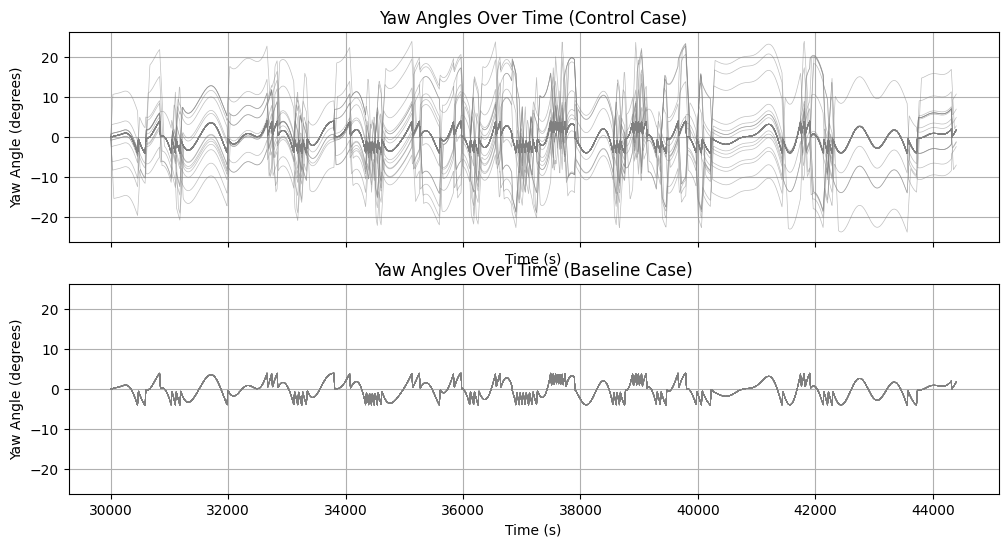

In [39]:
# Plot the yaw angles over time for all turbines in both cases
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True, sharey=True)

# Plot the yaw angles for the control case
for i in range(1, 70):  # Assuming there are 10 turbines
    ax[0].plot(appl_con['time'][i-1::69], appl_con['yaw'][i-1::69], color='gray', lw=0.5, alpha=0.5)
ax[0].set_title('Yaw Angles Over Time (Control Case)')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Yaw Angle (degrees)')
ax[0].grid()

# Plot the yaw angles for the baseline case
for i in range(1, 70):  # Assuming there are 10 turbines
    ax[1].plot(appl_bas['time'][i-1::69], appl_bas['yaw'][i-1::69], color='gray', lw=0.5, alpha=0.5)
ax[1].set_title('Yaw Angles Over Time (Baseline Case)')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Yaw Angle (degrees)')
ax[1].grid()


In [57]:
# Calculate the farm power for both cases by summing the power of all turbines at each time step
farm_power_con = meas_con.groupby('time')['power_OFF'].sum()
farm_power_bas = meas_bas.groupby('time')['power_OFF'].sum()

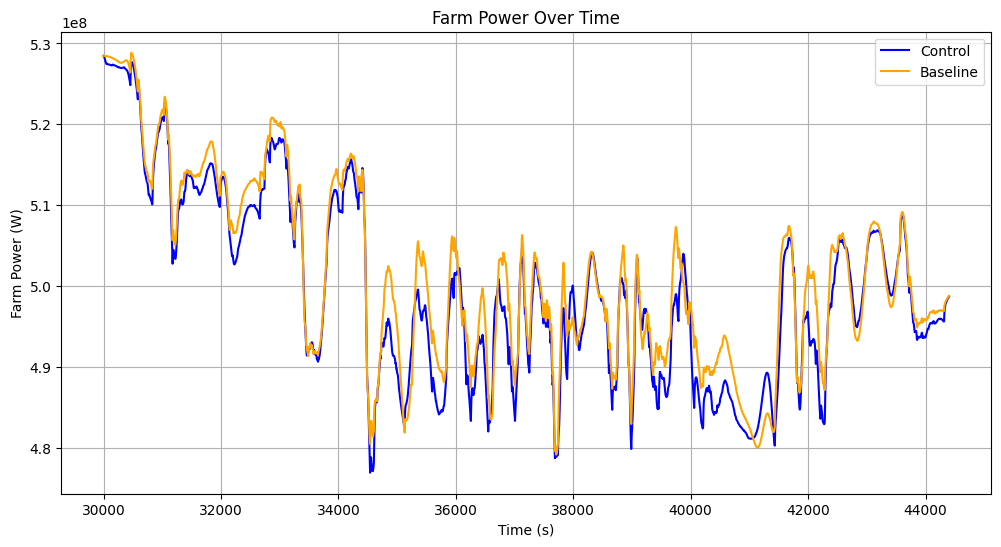

In [46]:
# Plot the farm power over time for both cases
plt.figure(figsize=(12, 6))
plt.plot(farm_power_con.index, farm_power_con.values, label='Control', color='blue')
plt.plot(farm_power_bas.index, farm_power_bas.values, label='Baseline', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Farm Power (W)')
plt.title('Farm Power Over Time')
plt.legend()
plt.grid()
plt.show()

In [58]:
# Calculate overall farm energy increase in percentage
delta_t = farm_power_con.index[1] - farm_power_con.index[0]  # Assuming uniform time steps
total_power_con = farm_power_con.sum() / 1e9  * delta_t/3600  # Convert to GWh
total_power_bas = farm_power_bas.sum() / 1e9  * delta_t/3600  # Convert to GWh
power_increase = ((total_power_con - total_power_bas) / total_power_bas) * 100
print(power_increase)
print(f"Total Farm Energy (Control): {total_power_con:.2f} GWh")
print(f"Total Farm Energy (Baseline): {total_power_bas:.2f} GWh")
print(f"Overall Farm Energy Increase: {power_increase:.2f}%")

-0.40822870586328275
Total Farm Energy (Control): 1.96 GWh
Total Farm Energy (Baseline): 1.97 GWh
Overall Farm Energy Increase: -0.41%


In [45]:
# Calculate the turbine energy for both cases
try:
    turb_energ_con  = meas_con.groupby('t_idx')['Power_PyWake'].sum() 
    turb_energ_bas  = meas_bas.groupby('t_idx')['Power_PyWake'].sum()
except KeyError:
    print("Power_PyWake column not found in measurements. Using power_OFF instead.")
    turb_energ_con  = meas_con.groupby('t_idx')['Power_FLORIS'].sum() 
    turb_energ_bas  = meas_bas.groupby('t_idx')['Power_FLORIS'].sum()

turb_eff_con    = turb_energ_con / turb_energ_bas

Power_PyWake column not found in measurements. Using power_OFF instead.


In [48]:
layout_x =[
    0.0,
    1.6403662,
    5.03577465,
    3.28073239,
    10.07653521,
    4.92109851,
    16.0546478,
    6.56146479,
    15.37656338,
    15.03752113,
    24.99439437,
    10.3457746,
    30.58859155,
    23.5684225,
    12.0010985,
    36.10,
    19.3902253,
    13.6614084,
    32.2090140,
    41.7420845,
    15.6707323,
    27.5122816,
    22.6210985,
    40.7,
    47.3412676,
    18.3182535,
    34.562366,
    49.20,
    20.9657746,
    41.8816901,
    38.037549,
    32.6527605,
    28.2103098,
    23.6132957,
    26.260816,
    47.9545352,
    45.0726760,
    39.8972957,
    34.8365915,
    30.4938591,
    51.2901126,
    58.4249577,
    33.211183,
    46.2692957,
    43.382450,
    62.6081408,
    35.9235211,
    41.2534647,
    57.7568450,
    38.6358591,
    67.3447605,
    61.0425633,
    56.7945633,
    52.6113802,
    71.4282253,
    50.7017746,
    71.2587042,
    49.8242535,
    43.6915774,
    71.1839154,
    71.2686760,
    49.3555774,
    71.5528732,
    68.6909577,
    66.2179436,
    63.6900845,
    61.1622253,
    58.634366,
    54.93980282
    ]
layout_y=[
0.0,
4.15825352,
0.4587042,
8.3165070,
0.9223943,
12.4747605,
3.6098028,
16.6330140,
9.7723943,
15.6158873,
8.1818873,
26.2358873,
3.4502535,
14.6087323,
30.4340281,
4.1333239,
26.3505633,
34.6321690,
13.5766478,
4.7067042,
38.650816,
25.4082253,
34.2482535,
12.5744788,
5.0756619,
42.3254366,
23.3490422,
11.6670422,
46.0000563,
24.3910985,
29.5216056,
36.0930422,
43.9658028,
49.6696901,
53.3443098,
27.9859436,
36.1429014,
43.1381408,
52.7908732,
59.2227042,
38.7555211,
32.3685633,
63.0020281,
47.5157746,
53.583633,
34.3529577,
66.7813521,
60.6835774,
39.518366,
70.5606760,
36.8907887,
45.5463380,
51.7238873,
58.6243943,
40.131633,
64.8717464,
44.6289295,
71.3933239,
77.590816,
49.1312112,
53.6534366,
79.0516901,
58.1457464,
62.1245070,
66.1082535,
69.8875774,
73.6669014,
77.44123944,
80.76684507]

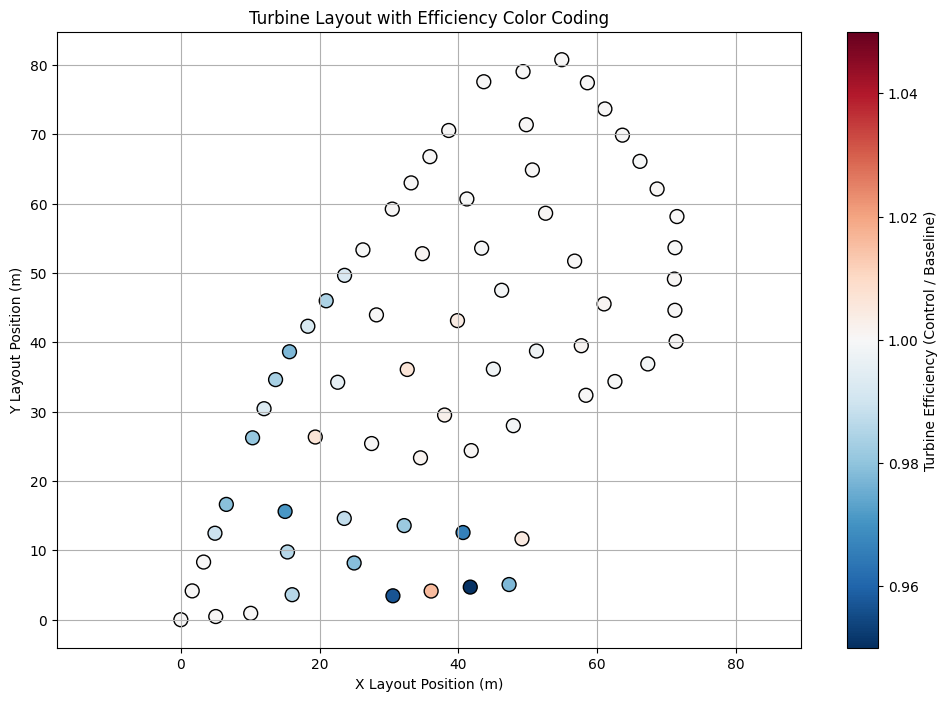

In [34]:
# Create a scatter plot of the turbine layout, color-coded by the turbine efficiency
plt.figure(figsize=(12, 8))
scatter = plt.scatter(layout_x, layout_y, c=turb_eff_con.values, cmap='RdBu_r', s=100, edgecolor='k', vmin=0.95, vmax=1.05)  # Set vmin and vmax for better color contrast
plt.colorbar(scatter, label='Turbine Efficiency (Control / Baseline)')
plt.xlabel('X Layout Position (m)')
plt.ylabel('Y Layout Position (m)')
plt.title('Turbine Layout with Efficiency Color Coding')
plt.axis('equal')  # Ensure equal aspect ratio for x and y axes
plt.grid()
plt.show()